In [6]:
# ===========================================================================================
# PROJECT: PHÂN LOẠI LOÀI HOA IRIS SỬ DỤNG THUẬT TOÁN NAIVE BAYES
# ===========================================================================================

# 1. Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings

warnings.filterwarnings("ignore")

# Thiết lập style cho đồ thị
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

print("✓ Đã import thành công các thư viện cần thiết!")


✓ Đã import thành công các thư viện cần thiết!


# 📊 Bước 1: Load và Khám Phá Dữ Liệu Iris

Tập dữ liệu Iris là một trong những tập dữ liệu kinh điển nhất trong Machine Learning, bao gồm:

- **150 mẫu** của 3 loài hoa Iris
- **4 đặc trưng**: chiều dài đài hoa, chiều rộng đài hoa, chiều dài cánh hoa, chiều rộng cánh hoa
- **3 lớp**: Iris-setosa, Iris-versicolor, Iris-virginica


In [7]:
# Load dữ liệu từ file
column_names = [
    "sepal_length_cm",
    "sepal_width_cm",
    "petal_length_cm",
    "petal_width_cm",
    "class",
]

data_path = (
    r"D:\Workspace\Mon_Hoc\Mon_hoc\KPDL_TEAM\LAB_NAIVE_BAYES\data\iris_data\iris.data"
)
df = pd.read_csv(data_path, header=None, names=column_names)

# Loại bỏ dòng trống nếu có
df = df.dropna()

print("=" * 70)
print("THÔNG TIN CƠ BẢN VỀ TẬP DỮ LIỆU")
print("=" * 70)
print(f"Kích thước dữ liệu: {df.shape[0]} mẫu, {df.shape[1]} cột")
print(f"\nCác cột: {list(df.columns)}")
print(f"\nKiểu dữ liệu:\n{df.dtypes}")
print(f"\n5 mẫu đầu tiên:")
print(df.head())


THÔNG TIN CƠ BẢN VỀ TẬP DỮ LIỆU
Kích thước dữ liệu: 150 mẫu, 5 cột

Các cột: ['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm', 'class']

Kiểu dữ liệu:
sepal_length_cm    float64
sepal_width_cm     float64
petal_length_cm    float64
petal_width_cm     float64
class               object
dtype: object

5 mẫu đầu tiên:
   sepal_length_cm  sepal_width_cm  petal_length_cm  petal_width_cm  \
0              5.1             3.5              1.4             0.2   
1              4.9             3.0              1.4             0.2   
2              4.7             3.2              1.3             0.2   
3              4.6             3.1              1.5             0.2   
4              5.0             3.6              1.4             0.2   

         class  
0  Iris-setosa  
1  Iris-setosa  
2  Iris-setosa  
3  Iris-setosa  
4  Iris-setosa  


In [8]:
# Phân tích thống kê mô tả
print("\n" + "=" * 70)
print("THỐNG KÊ MÔ TẢ")
print("=" * 70)
print(df.describe())

# Kiểm tra phân bố các lớp
print("\n" + "=" * 70)
print("PHÂN BỐ CÁC LOÀI HOA")
print("=" * 70)
class_counts = df["class"].value_counts()
print(class_counts)
print(f"\nTổng số mẫu: {class_counts.sum()}")



THỐNG KÊ MÔ TẢ
       sepal_length_cm  sepal_width_cm  petal_length_cm  petal_width_cm
count       150.000000      150.000000       150.000000      150.000000
mean          5.843333        3.054000         3.758667        1.198667
std           0.828066        0.433594         1.764420        0.763161
min           4.300000        2.000000         1.000000        0.100000
25%           5.100000        2.800000         1.600000        0.300000
50%           5.800000        3.000000         4.350000        1.300000
75%           6.400000        3.300000         5.100000        1.800000
max           7.900000        4.400000         6.900000        2.500000

PHÂN BỐ CÁC LOÀI HOA
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Tổng số mẫu: 150


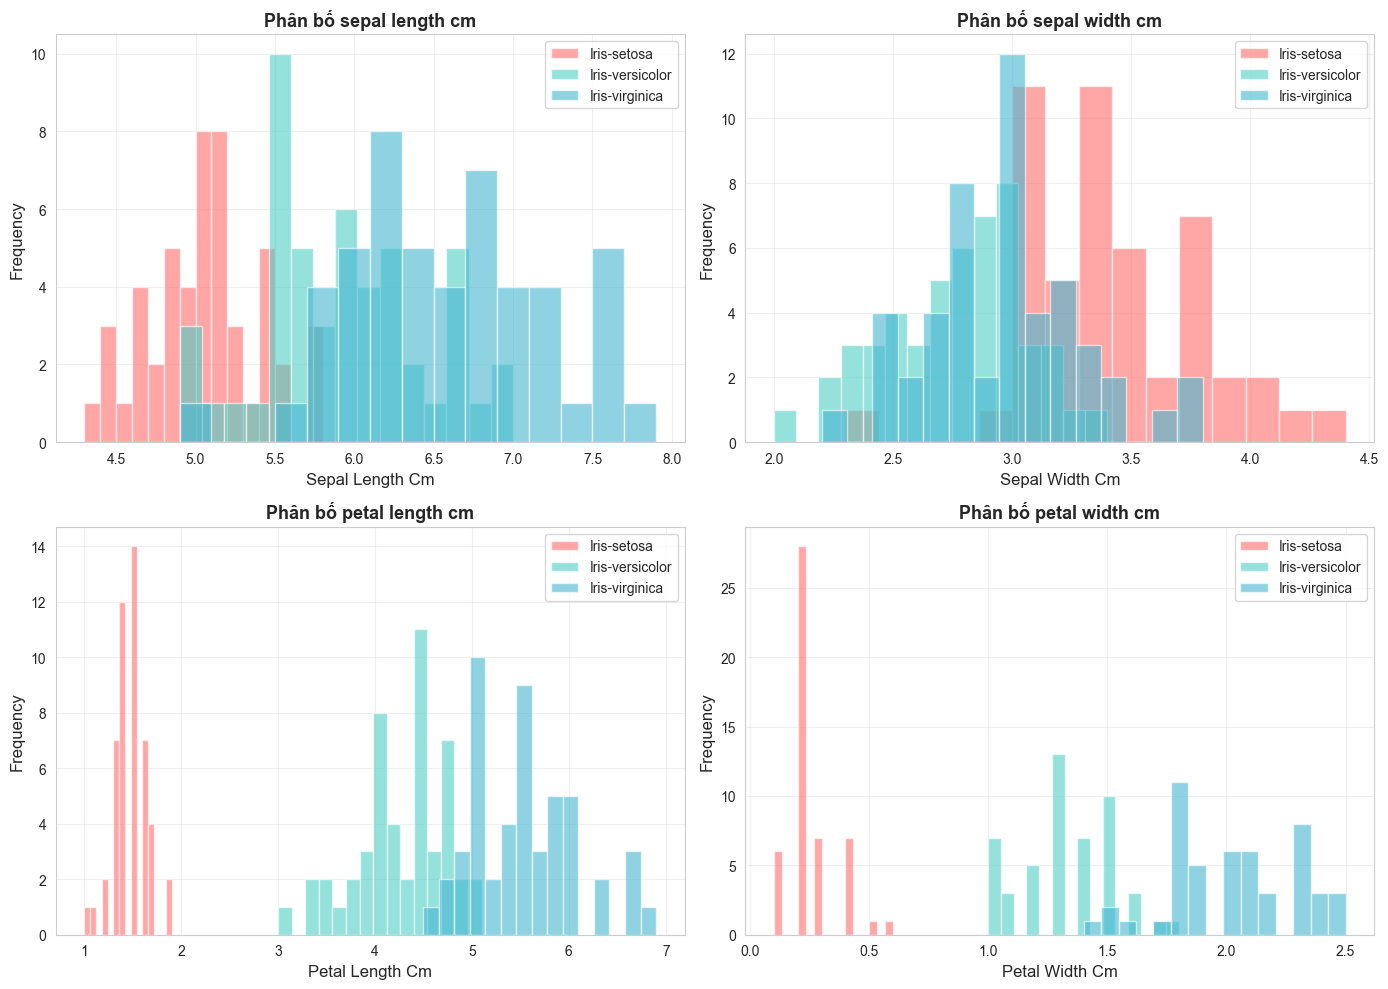

✓ Đã vẽ biểu đồ phân bố các đặc trưng!


In [9]:
# Visualize phân bố các đặc trưng
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = ["sepal_length_cm", "sepal_width_cm", "petal_length_cm", "petal_width_cm"]
colors = ["#FF6B6B", "#4ECDC4", "#45B7D1"]

for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    for i, species in enumerate(df["class"].unique()):
        data = df[df["class"] == species][feature]
        ax.hist(data, alpha=0.6, label=species, bins=15, color=colors[i])

    ax.set_xlabel(feature.replace("_", " ").title(), fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_title(f'Phân bố {feature.replace("_", " ")}', fontsize=13, fontweight="bold")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("iris_feature_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Đã vẽ biểu đồ phân bố các đặc trưng!")


<Figure size 1200x1000 with 0 Axes>

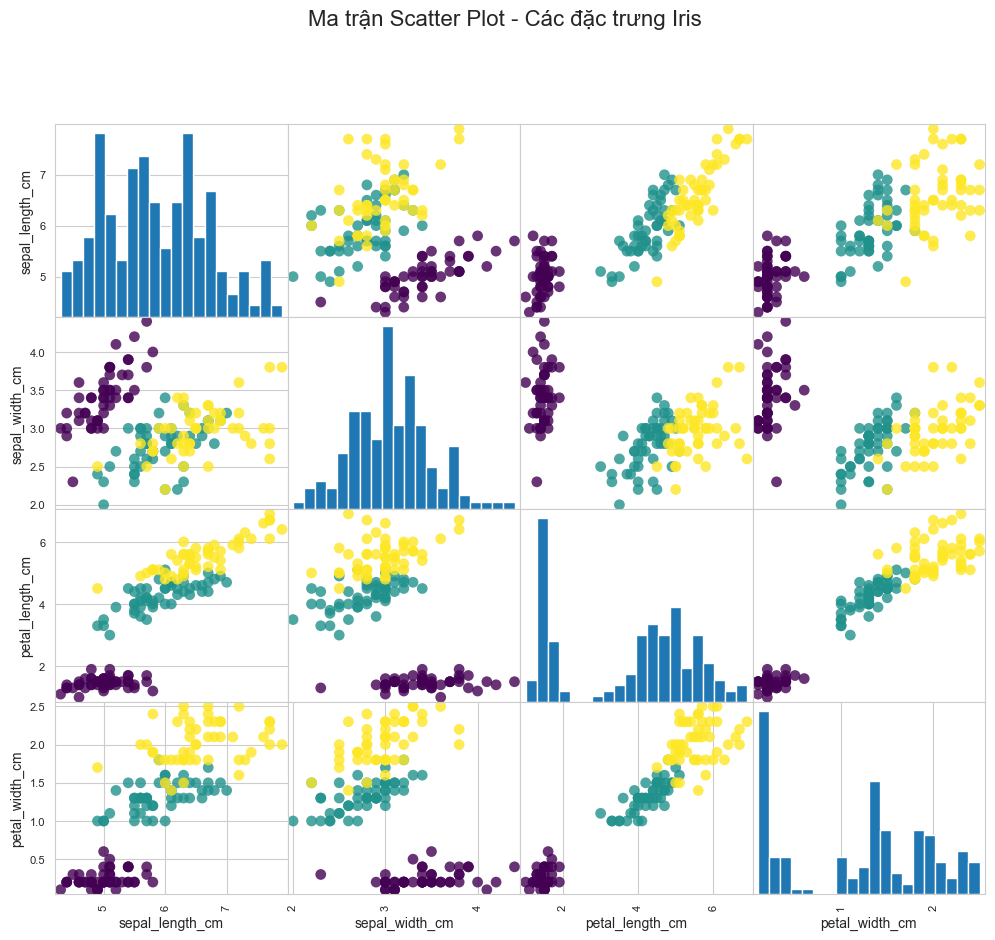

✓ Đã vẽ ma trận scatter plot!


In [10]:
# Vẽ pairplot để xem mối quan hệ giữa các đặc trưng
plt.figure(figsize=(12, 10))
pd.plotting.scatter_matrix(
    df[features],
    figsize=(12, 10),
    c=df["class"].astype("category").cat.codes,
    marker="o",
    hist_kwds={"bins": 20},
    s=60,
    alpha=0.8,
    cmap="viridis",
)
plt.suptitle("Ma trận Scatter Plot - Các đặc trưng Iris", fontsize=16, y=0.995)
plt.savefig("iris_pairplot.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Đã vẽ ma trận scatter plot!")


# 🔧 Bước 2: Tiền Xử Lý Dữ Liệu

Chuẩn bị dữ liệu để huấn luyện mô hình


In [11]:
# Kiểm tra missing values
print("=" * 70)
print("KIỂM TRA MISSING VALUES")
print("=" * 70)
print(df.isnull().sum())
print(f"\nTổng số missing values: {df.isnull().sum().sum()}")

# Tách features và labels
X = df.drop("class", axis=1).values
y = df["class"].values

print(f"\n✓ Shape của X (features): {X.shape}")
print(f"✓ Shape của y (labels): {y.shape}")
print(f"\nCác lớp duy nhất: {np.unique(y)}")


KIỂM TRA MISSING VALUES
sepal_length_cm    0
sepal_width_cm     0
petal_length_cm    0
petal_width_cm     0
class              0
dtype: int64

Tổng số missing values: 0

✓ Shape của X (features): (150, 4)
✓ Shape của y (labels): (150,)

Các lớp duy nhất: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [12]:
# Chia dữ liệu thành tập train và test (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=" * 70)
print("PHÂN CHIA DỮ LIỆU")
print("=" * 70)
print(f"Tập huấn luyện (Train): {X_train.shape[0]} mẫu")
print(f"Tập kiểm tra (Test): {X_test.shape[0]} mẫu")
print(f"Tỉ lệ: {X_train.shape[0]/len(X)*100:.1f}% - {X_test.shape[0]/len(X)*100:.1f}%")

# Kiểm tra phân bố các lớp trong train/test
print(f"\nPhân bố trong tập train:")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label}: {count} mẫu ({count/len(y_train)*100:.1f}%)")

print(f"\nPhân bố trong tập test:")
unique, counts = np.unique(y_test, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label}: {count} mẫu ({count/len(y_test)*100:.1f}%)")


PHÂN CHIA DỮ LIỆU
Tập huấn luyện (Train): 120 mẫu
Tập kiểm tra (Test): 30 mẫu
Tỉ lệ: 80.0% - 20.0%

Phân bố trong tập train:
  Iris-setosa: 40 mẫu (33.3%)
  Iris-versicolor: 40 mẫu (33.3%)
  Iris-virginica: 40 mẫu (33.3%)

Phân bố trong tập test:
  Iris-setosa: 10 mẫu (33.3%)
  Iris-versicolor: 10 mẫu (33.3%)
  Iris-virginica: 10 mẫu (33.3%)


# 🤖 Bước 3: Cài Đặt Thuật Toán Naive Bayes Từ Đầu

## Giải thích thuật toán Gaussian Naive Bayes:

**Công thức xác suất:**
$$P(y|X) = \frac{P(X|y) \cdot P(y)}{P(X)}$$

Với Gaussian Naive Bayes, giả định rằng các đặc trưng tuân theo phân phối chuẩn:
$$P(x_i|y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i-\mu_y)^2}{2\sigma_y^2}\right)$$

Trong đó:

- $\mu_y$ là trung bình của đặc trưng $x_i$ trong lớp $y$
- $\sigma_y^2$ là phương sai của đặc trưng $x_i$ trong lớp $y$


In [13]:
class GaussianNaiveBayesCustom:
    """
    Cài đặt thuật toán Gaussian Naive Bayes từ đầu
    """

    def __init__(self):
        self.classes = None
        self.mean = {}
        self.var = {}
        self.priors = {}

    def fit(self, X, y):
        """
        Huấn luyện model

        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Training data
        y : array-like, shape (n_samples,)
            Target values
        """
        self.classes = np.unique(y)
        n_samples = X.shape[0]

        # Tính toán mean, variance và prior cho mỗi class
        for c in self.classes:
            X_c = X[y == c]

            # Mean và variance cho mỗi feature trong class c
            self.mean[c] = np.mean(X_c, axis=0)
            self.var[c] = np.var(X_c, axis=0)

            # Prior probability: P(y=c)
            self.priors[c] = X_c.shape[0] / n_samples

        print("✓ Model đã được huấn luyện!")
        print(f"  - Số lượng classes: {len(self.classes)}")
        print(f"  - Classes: {self.classes}")

    def _calculate_likelihood(self, x, mean, var):
        """
        Tính likelihood với phân phối Gaussian
        P(x|y) = (1/sqrt(2*pi*var)) * exp(-(x-mean)^2 / (2*var))
        """
        eps = 1e-4  # Tránh chia cho 0
        coeff = 1.0 / np.sqrt(2.0 * np.pi * var + eps)
        exponent = np.exp(-((x - mean) ** 2) / (2 * var + eps))
        return coeff * exponent

    def _calculate_posterior(self, x):
        """
        Tính posterior probability cho tất cả các classes
        """
        posteriors = []

        for c in self.classes:
            # Prior: P(y=c)
            prior = np.log(self.priors[c])

            # Likelihood: P(x|y=c) cho tất cả features
            # Sử dụng log để tránh underflow
            likelihood = np.sum(
                np.log(self._calculate_likelihood(x, self.mean[c], self.var[c]))
            )

            # Posterior: P(y=c|x) = P(x|y=c) * P(y=c)
            posterior = prior + likelihood
            posteriors.append(posterior)

        return self.classes[np.argmax(posteriors)]

    def predict(self, X):
        """
        Dự đoán class cho dữ liệu mới
        """
        predictions = [self._calculate_posterior(x) for x in X]
        return np.array(predictions)

    def score(self, X, y):
        """
        Tính accuracy
        """
        predictions = self.predict(X)
        return np.mean(predictions == y)


print("✓ Đã định nghĩa class GaussianNaiveBayesCustom!")


✓ Đã định nghĩa class GaussianNaiveBayesCustom!


# 🎯 Bước 4: Huấn Luyện và Đánh Giá Model

## 4.1. Model tự cài đặt (Custom)


In [14]:
# Huấn luyện model custom
print("=" * 70)
print("HUẤN LUYỆN MODEL TỰ CÀI ĐẶT")
print("=" * 70)

model_custom = GaussianNaiveBayesCustom()
model_custom.fit(X_train, y_train)

# Dự đoán trên tập test
y_pred_custom = model_custom.predict(X_test)

# Đánh giá
accuracy_custom = accuracy_score(y_test, y_pred_custom)
print(f"\n{'='*70}")
print(f"KẾT QUẢ MODEL TỰ CÀI ĐẶT")
print(f"{'='*70}")
print(f"Accuracy trên tập test: {accuracy_custom:.4f} ({accuracy_custom*100:.2f}%)")

print(f"\n{'='*70}")
print("CONFUSION MATRIX")
print(f"{'='*70}")
cm_custom = confusion_matrix(y_test, y_pred_custom)
print(cm_custom)

print(f"\n{'='*70}")
print("CLASSIFICATION REPORT")
print(f"{'='*70}")
print(classification_report(y_test, y_pred_custom))


HUẤN LUYỆN MODEL TỰ CÀI ĐẶT
✓ Model đã được huấn luyện!
  - Số lượng classes: 3
  - Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

KẾT QUẢ MODEL TỰ CÀI ĐẶT
Accuracy trên tập test: 0.9667 (96.67%)

CONFUSION MATRIX
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

CLASSIFICATION REPORT
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



## 4.2. Model sklearn (So sánh)


In [15]:
# Huấn luyện model sklearn để so sánh
print("=" * 70)
print("HUẤN LUYỆN MODEL SKLEARN")
print("=" * 70)

model_sklearn = GaussianNB()
model_sklearn.fit(X_train, y_train)
print("✓ Model sklearn đã được huấn luyện!")

# Dự đoán
y_pred_sklearn = model_sklearn.predict(X_test)

# Đánh giá
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f"\n{'='*70}")
print(f"KẾT QUẢ MODEL SKLEARN")
print(f"{'='*70}")
print(f"Accuracy trên tập test: {accuracy_sklearn:.4f} ({accuracy_sklearn*100:.2f}%)")

print(f"\n{'='*70}")
print("CONFUSION MATRIX")
print(f"{'='*70}")
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
print(cm_sklearn)

print(f"\n{'='*70}")
print("CLASSIFICATION REPORT")
print(f"{'='*70}")
print(classification_report(y_test, y_pred_sklearn))


HUẤN LUYỆN MODEL SKLEARN
✓ Model sklearn đã được huấn luyện!

KẾT QUẢ MODEL SKLEARN
Accuracy trên tập test: 0.9667 (96.67%)

CONFUSION MATRIX
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

CLASSIFICATION REPORT
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [16]:
# So sánh kết quả giữa 2 model
print("=" * 70)
print("SO SÁNH KẾT QUẢ")
print("=" * 70)
comparison_df = pd.DataFrame(
    {
        "Model": ["Custom Implementation", "Sklearn GaussianNB"],
        "Accuracy": [accuracy_custom, accuracy_sklearn],
        "Accuracy (%)": [accuracy_custom * 100, accuracy_sklearn * 100],
    }
)
print(comparison_df.to_string(index=False))
print(f"\nChênh lệch: {abs(accuracy_custom - accuracy_sklearn)*100:.4f}%")


SO SÁNH KẾT QUẢ
                Model  Accuracy  Accuracy (%)
Custom Implementation  0.966667     96.666667
   Sklearn GaussianNB  0.966667     96.666667

Chênh lệch: 0.0000%


# 📊 Bước 5: Visualization và Demo

## 5.1. Vẽ Confusion Matrix


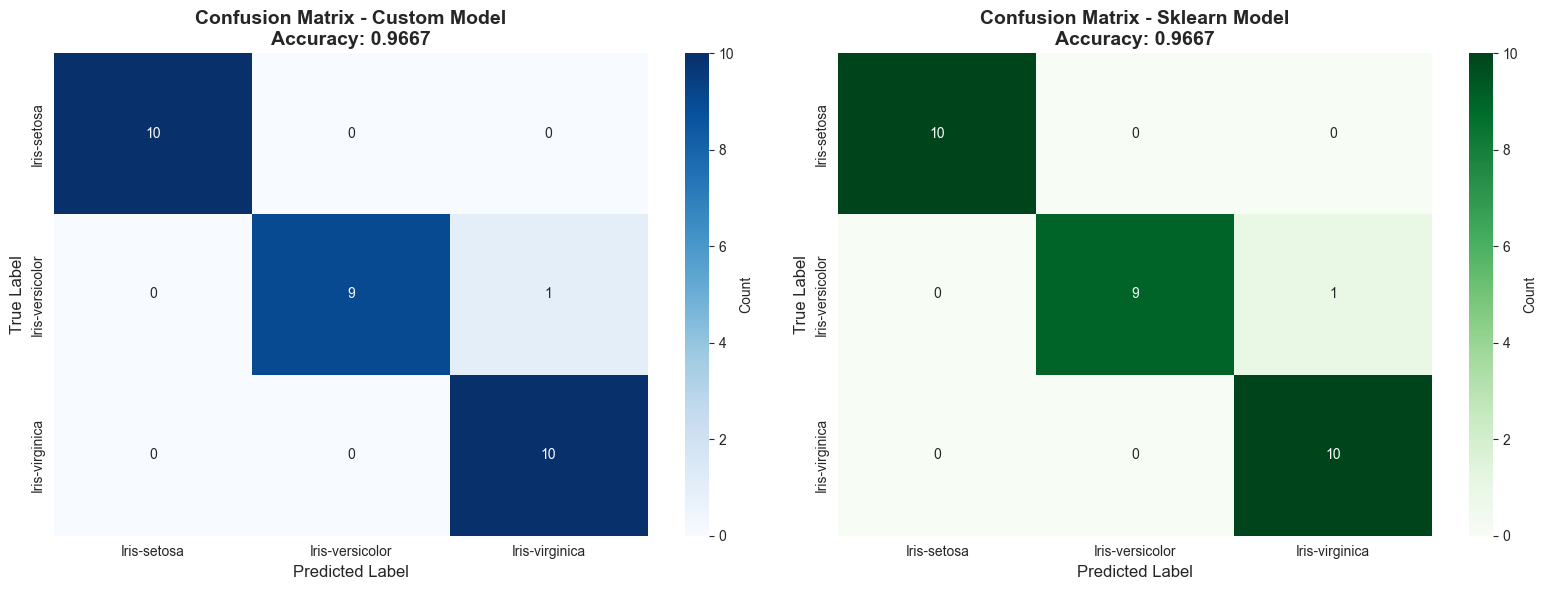

✓ Đã vẽ confusion matrices!


In [17]:
# Vẽ confusion matrix cho cả 2 models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Custom Model
sns.heatmap(
    cm_custom,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=np.unique(y_test),
    yticklabels=np.unique(y_test),
    ax=axes[0],
    cbar_kws={"label": "Count"},
)
axes[0].set_title(
    "Confusion Matrix - Custom Model\n" + f"Accuracy: {accuracy_custom:.4f}",
    fontsize=14,
    fontweight="bold",
)
axes[0].set_ylabel("True Label", fontsize=12)
axes[0].set_xlabel("Predicted Label", fontsize=12)

# Sklearn Model
sns.heatmap(
    cm_sklearn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=np.unique(y_test),
    yticklabels=np.unique(y_test),
    ax=axes[1],
    cbar_kws={"label": "Count"},
)
axes[1].set_title(
    "Confusion Matrix - Sklearn Model\n" + f"Accuracy: {accuracy_sklearn:.4f}",
    fontsize=14,
    fontweight="bold",
)
axes[1].set_ylabel("True Label", fontsize=12)
axes[1].set_xlabel("Predicted Label", fontsize=12)

plt.tight_layout()
plt.savefig("confusion_matrices_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Đã vẽ confusion matrices!")


## 5.2. Phân tích lỗi phân loại


In [18]:
# Phân tích các mẫu bị phân loại sai
misclassified_indices = np.where(y_pred_custom != y_test)[0]

if len(misclassified_indices) > 0:
    print("=" * 70)
    print(f"PHÂN TÍCH CÁC MẪU BỊ PHÂN LOẠI SAI")
    print("=" * 70)
    print(f"Tổng số mẫu bị phân loại sai: {len(misclassified_indices)}/{len(y_test)}")
    print()

    for idx in misclassified_indices[:5]:  # Hiển thị 5 mẫu đầu tiên
        print(f"Mẫu #{idx}:")
        print(f"  Features: {X_test[idx]}")
        print(f"  True label: {y_test[idx]}")
        print(f"  Predicted: {y_pred_custom[idx]}")
        print()
else:
    print("✓ Model phân loại chính xác 100% trên tập test!")


PHÂN TÍCH CÁC MẪU BỊ PHÂN LOẠI SAI
Tổng số mẫu bị phân loại sai: 1/30

Mẫu #25:
  Features: [6.7 3.  5.  1.7]
  True label: Iris-versicolor
  Predicted: Iris-virginica



## 5.3. Function Demo - Dự đoán loài hoa mới


In [19]:
def predict_iris_species(
    sepal_length,
    sepal_width,
    petal_length,
    petal_width,
    model=model_custom,
    show_details=True,
):
    """
    Dự đoán loài hoa Iris dựa trên các đặc trưng đầu vào

    Parameters:
    -----------
    sepal_length : float
        Chiều dài đài hoa (cm)
    sepal_width : float
        Chiều rộng đài hoa (cm)
    petal_length : float
        Chiều dài cánh hoa (cm)
    petal_width : float
        Chiều rộng cánh hoa (cm)
    model : object
        Model đã được huấn luyện (mặc định là custom model)
    show_details : bool
        Hiển thị chi tiết dự đoán

    Returns:
    --------
    str : Tên loài hoa được dự đoán
    """

    # Tạo input features
    features = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

    # Dự đoán
    prediction = model.predict(features)[0]

    if show_details:
        print("=" * 70)
        print("DỰ ĐOÁN LOÀI HOA IRIS")
        print("=" * 70)
        print(f"Đặc trưng đầu vào:")
        print(f"  • Chiều dài đài hoa (Sepal Length): {sepal_length} cm")
        print(f"  • Chiều rộng đài hoa (Sepal Width): {sepal_width} cm")
        print(f"  • Chiều dài cánh hoa (Petal Length): {petal_length} cm")
        print(f"  • Chiều rộng cánh hoa (Petal Width): {petal_width} cm")
        print(f"\n{'='*70}")
        print(f"KẾT QUẢ DỰ ĐOÁN: {prediction}")
        print(f"{'='*70}")

        # Thêm thông tin về loài
        species_info = {
            "Iris-setosa": "Loài Iris Setosa - thường có cánh hoa nhỏ",
            "Iris-versicolor": "Loài Iris Versicolor - có kích thước trung bình",
            "Iris-virginica": "Loài Iris Virginica - thường có cánh hoa lớn",
        }
        print(f"ℹ️  {species_info.get(prediction, 'Thông tin không có')}")
        print("=" * 70)

    return prediction


print("✓ Đã định nghĩa function predict_iris_species!")


✓ Đã định nghĩa function predict_iris_species!


### 🎮 Test Demo với các mẫu khác nhau


In [20]:
# Test với một vài mẫu ví dụ

# Mẫu 1: Đặc trưng giống Iris-setosa (cánh hoa nhỏ)
print("TEST 1: Mẫu có đặc trưng Iris-setosa\n")
result1 = predict_iris_species(5.1, 3.5, 1.4, 0.2)
print()

# Mẫu 2: Đặc trưng giống Iris-versicolor (kích thước trung bình)
print("\nTEST 2: Mẫu có đặc trưng Iris-versicolor\n")
result2 = predict_iris_species(6.4, 3.2, 4.5, 1.5)
print()

# Mẫu 3: Đặc trưng giống Iris-virginica (cánh hoa lớn)
print("\nTEST 3: Mẫu có đặc trưng Iris-virginica\n")
result3 = predict_iris_species(6.5, 3.0, 5.8, 2.2)
print()


TEST 1: Mẫu có đặc trưng Iris-setosa

DỰ ĐOÁN LOÀI HOA IRIS
Đặc trưng đầu vào:
  • Chiều dài đài hoa (Sepal Length): 5.1 cm
  • Chiều rộng đài hoa (Sepal Width): 3.5 cm
  • Chiều dài cánh hoa (Petal Length): 1.4 cm
  • Chiều rộng cánh hoa (Petal Width): 0.2 cm

KẾT QUẢ DỰ ĐOÁN: Iris-setosa
ℹ️  Loài Iris Setosa - thường có cánh hoa nhỏ


TEST 2: Mẫu có đặc trưng Iris-versicolor

DỰ ĐOÁN LOÀI HOA IRIS
Đặc trưng đầu vào:
  • Chiều dài đài hoa (Sepal Length): 6.4 cm
  • Chiều rộng đài hoa (Sepal Width): 3.2 cm
  • Chiều dài cánh hoa (Petal Length): 4.5 cm
  • Chiều rộng cánh hoa (Petal Width): 1.5 cm

KẾT QUẢ DỰ ĐOÁN: Iris-versicolor
ℹ️  Loài Iris Versicolor - có kích thước trung bình


TEST 3: Mẫu có đặc trưng Iris-virginica

DỰ ĐOÁN LOÀI HOA IRIS
Đặc trưng đầu vào:
  • Chiều dài đài hoa (Sepal Length): 6.5 cm
  • Chiều rộng đài hoa (Sepal Width): 3.0 cm
  • Chiều dài cánh hoa (Petal Length): 5.8 cm
  • Chiều rộng cánh hoa (Petal Width): 2.2 cm

KẾT QUẢ DỰ ĐOÁN: Iris-virginica
ℹ️  Loài Ir

## 5.4. Visualize Decision Boundaries (2D projection)


✓ Model đã được huấn luyện!
  - Số lượng classes: 3
  - Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


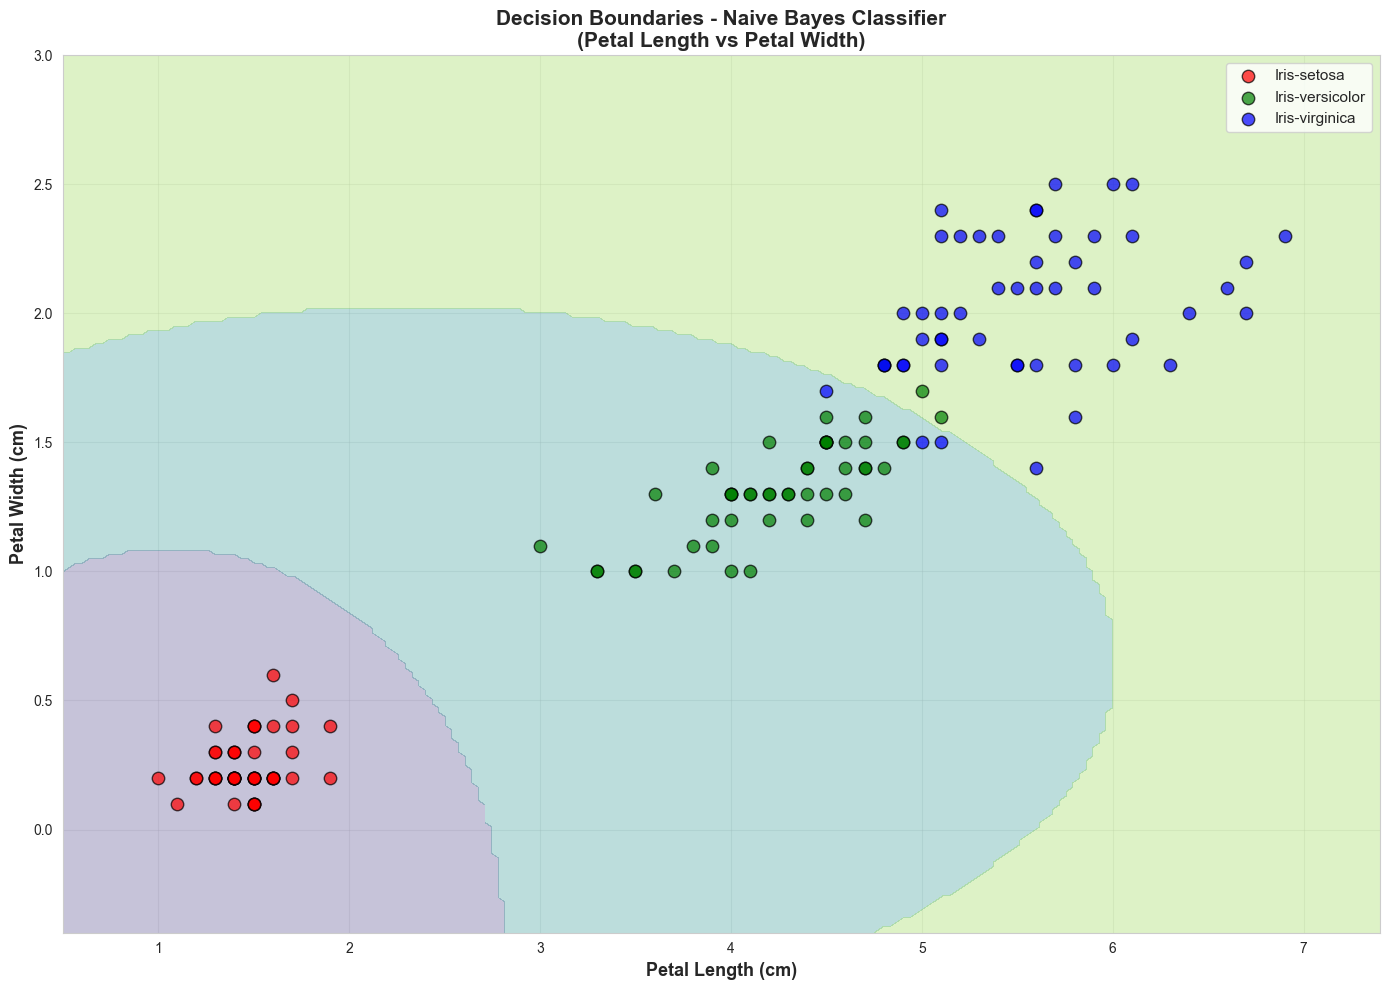

✓ Đã vẽ decision boundaries!
✓ Accuracy với 2 features: 0.9667


In [21]:
# Vẽ decision boundaries với 2 features quan trọng nhất (Petal length và Petal width)
# Vì đây là 2 features phân biệt rõ ràng nhất giữa các loài

# Chỉ sử dụng 2 features: petal_length và petal_width (cột 2 và 3)
X_2d = X[:, 2:4]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y
)

# Huấn luyện model với 2 features
model_2d = GaussianNaiveBayesCustom()
model_2d.fit(X_train_2d, y_train_2d)

# Tạo mesh grid
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

# Dự đoán trên mesh grid
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])

# Chuyển đổi labels thành số để vẽ
label_to_num = {label: i for i, label in enumerate(np.unique(y))}
Z_num = np.array([label_to_num[label] for label in Z])
Z_num = Z_num.reshape(xx.shape)

# Vẽ decision boundaries
plt.figure(figsize=(14, 10))
plt.contourf(xx, yy, Z_num, alpha=0.3, cmap="viridis", levels=2)

# Vẽ các điểm dữ liệu
colors = ["red", "green", "blue"]
for i, species in enumerate(np.unique(y)):
    idx = y == species
    plt.scatter(
        X_2d[idx, 0],
        X_2d[idx, 1],
        c=colors[i],
        label=species,
        edgecolor="black",
        s=80,
        alpha=0.7,
    )

plt.xlabel("Petal Length (cm)", fontsize=13, fontweight="bold")
plt.ylabel("Petal Width (cm)", fontsize=13, fontweight="bold")
plt.title(
    "Decision Boundaries - Naive Bayes Classifier\n(Petal Length vs Petal Width)",
    fontsize=15,
    fontweight="bold",
)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("decision_boundaries.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"✓ Đã vẽ decision boundaries!")
print(f"✓ Accuracy với 2 features: {model_2d.score(X_test_2d, y_test_2d):.4f}")


# 📝 Tổng Kết và Kết Luận


In [22]:
print("=" * 80)
print(" " * 20 + "📊 TỔNG KẾT PROJECT 📊")
print("=" * 80)

print("\n🎯 THÔNG TIN DỮ LIỆU:")
print(f"  • Tập dữ liệu: Iris Dataset")
print(f"  • Số mẫu: {len(X)} (Train: {len(X_train)}, Test: {len(X_test)})")
print(f"  • Số features: {X.shape[1]}")
print(f"  • Số classes: {len(np.unique(y))}")

print("\n🤖 THUẬT TOÁN:")
print(f"  • Gaussian Naive Bayes")
print(f"  • Giả định: Các features tuân theo phân phối chuẩn (Gaussian)")
print(f"  • Độc lập điều kiện giữa các features")

print("\n📈 KẾT QUẢ:")
print(
    f"  • Custom Implementation Accuracy: {accuracy_custom:.4f} ({accuracy_custom*100:.2f}%)"
)
print(
    f"  • Sklearn Implementation Accuracy: {accuracy_sklearn:.4f} ({accuracy_sklearn*100:.2f}%)"
)
print(f"  • Chênh lệch: {abs(accuracy_custom - accuracy_sklearn)*100:.4f}%")

print("\n✅ ƯU ĐIỂM CỦA NAIVE BAYES:")
print(f"  • Đơn giản, dễ implement")
print(f"  • Training nhanh")
print(f"  • Hoạt động tốt với dữ liệu nhỏ")
print(f"  • Cho kết quả xác suất")
print(f"  • Ít bị overfit")

print("\n⚠️  HẠN CHẾ:")
print(f"  • Giả định độc lập điều kiện có thể không đúng trong thực tế")
print(f"  • Giả định phân phối chuẩn có thể không phù hợp với tất cả dữ liệu")
print(f"  • Kém hiệu quả nếu features có tương quan cao")

print("\n🎓 BÀI HỌC RÚT RA:")
print(f"  • Naive Bayes rất hiệu quả cho bài toán Iris classification")
print(f"  • Implementation từ đầu giúp hiểu sâu về thuật toán")
print(f"  • Model đơn giản có thể đạt accuracy cao trên dữ liệu phù hợp")

print("\n" + "=" * 80)
print(" " * 25 + "🎉 HOÀN THÀNH PROJECT! 🎉")
print("=" * 80)


                    📊 TỔNG KẾT PROJECT 📊

🎯 THÔNG TIN DỮ LIỆU:
  • Tập dữ liệu: Iris Dataset
  • Số mẫu: 150 (Train: 120, Test: 30)
  • Số features: 4
  • Số classes: 3

🤖 THUẬT TOÁN:
  • Gaussian Naive Bayes
  • Giả định: Các features tuân theo phân phối chuẩn (Gaussian)
  • Độc lập điều kiện giữa các features

📈 KẾT QUẢ:
  • Custom Implementation Accuracy: 0.9667 (96.67%)
  • Sklearn Implementation Accuracy: 0.9667 (96.67%)
  • Chênh lệch: 0.0000%

✅ ƯU ĐIỂM CỦA NAIVE BAYES:
  • Đơn giản, dễ implement
  • Training nhanh
  • Hoạt động tốt với dữ liệu nhỏ
  • Cho kết quả xác suất
  • Ít bị overfit

⚠️  HẠN CHẾ:
  • Giả định độc lập điều kiện có thể không đúng trong thực tế
  • Giả định phân phối chuẩn có thể không phù hợp với tất cả dữ liệu
  • Kém hiệu quả nếu features có tương quan cao

🎓 BÀI HỌC RÚT RA:
  • Naive Bayes rất hiệu quả cho bài toán Iris classification
  • Implementation từ đầu giúp hiểu sâu về thuật toán
  • Model đơn giản có thể đạt accuracy cao trên dữ liệu phù hợp

 